In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [7]:
df = pd.read_csv('sportsref_download.csv')

In [8]:
df.head()

,Rk,Gcar,Gtm,Date,Team,Unnamed: 5,Opp,Result,GS,MP,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,+/-
0,1.0,957.0,1.0,10/23/24,GSW,@,POR,"W, 140-104",*,25:04:00,...,9.0,9.0,10.0,2.0,0.0,2.0,0.0,17.0,21.3,23.0
1,2.0,958.0,2.0,10/25/24,GSW,@,UTA,"W, 127-86",*,27:25:00,...,3.0,3.0,4.0,2.0,0.0,3.0,3.0,20.0,10.3,22.0
2,3.0,959.0,3.0,10/27/24,GSW,NaN,LAC,"L, 104-112",*,26:42:00,...,4.0,4.0,6.0,2.0,1.0,6.0,1.0,18.0,14.4,2.0
3,3.0,NaN,4.0,10/29/24,GSW,NaN,NOP,"W, 124-106",Inactive,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,NaN,5.0,10/30/24,GSW,NaN,NOP,"W, 104-89",Inactive,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# df = df[df['EPS'].notna()]

df = df[df['MP'].notna()]
df.head()

,Rk,Gcar,Gtm,Date,Team,Unnamed: 5,Opp,Result,GS,MP,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,+/-
0,1.0,957.0,1.0,10/23/24,GSW,@,POR,"W, 140-104",*,25:04:00,...,9.0,9.0,10.0,2.0,0.0,2.0,0.0,17.0,21.3,23.0
1,2.0,958.0,2.0,10/25/24,GSW,@,UTA,"W, 127-86",*,27:25:00,...,3.0,3.0,4.0,2.0,0.0,3.0,3.0,20.0,10.3,22.0
2,3.0,959.0,3.0,10/27/24,GSW,NaN,LAC,"L, 104-112",*,26:42:00,...,4.0,4.0,6.0,2.0,1.0,6.0,1.0,18.0,14.4,2.0
6,4.0,960.0,7.0,11/4/24,GSW,@,WAS,"W, 125-112",*,24:05:00,...,2.0,3.0,6.0,0.0,0.0,2.0,1.0,24.0,19.4,9.0
7,5.0,961.0,8.0,11/6/24,GSW,@,BOS,"W, 118-112",*,34:23:00,...,7.0,7.0,9.0,4.0,1.0,3.0,2.0,27.0,27.6,7.0


In [24]:
designation = {
    "@":'away',
    np.nan:'home'
}

df['Unnamed: 5'] = df['Unnamed: 5'].map(designation)



In [32]:
df = df.drop(['Result', 'Rk', 'Gcar', 'Gtm', 'Team'], axis=1)

In [36]:
df = df[:70]

In [41]:
df = df.rename(columns={'Unnamed: 5':'designation'})

In [42]:
df

,Date,designation,Opp,GS,MP,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,+/-
0,10/23/24,away,POR,*,25:04:00,4.0,10.0,0.400,3.0,7.0,...,9.0,9.0,10.0,2.0,0.0,2.0,0.0,17.0,21.3,23.0
1,10/25/24,away,UTA,*,27:25:00,7.0,20.0,0.350,4.0,13.0,...,3.0,3.0,4.0,2.0,0.0,3.0,3.0,20.0,10.3,22.0
2,10/27/24,home,LAC,*,26:42:00,6.0,11.0,0.545,4.0,7.0,...,4.0,4.0,6.0,2.0,1.0,6.0,1.0,18.0,14.4,2.0
6,11/4/24,away,WAS,*,24:05:00,7.0,15.0,0.467,4.0,9.0,...,2.0,3.0,6.0,0.0,0.0,2.0,1.0,24.0,19.4,9.0
7,11/6/24,away,BOS,*,34:23:00,8.0,17.0,0.471,4.0,9.0,...,7.0,7.0,9.0,4.0,1.0,3.0,2.0,27.0,27.6,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,4/6/25,home,HOU,*,32:40:00,1.0,10.0,0.100,1.0,8.0,...,2.0,2.0,8.0,0.0,0.0,4.0,0.0,3.0,-1.4,-4.0
78,4/8/25,away,PHO,*,25:55:00,9.0,17.0,0.529,3.0,9.0,...,8.0,9.0,6.0,1.0,1.0,2.0,0.0,25.0,23.7,31.0
79,4/9/25,home,SAS,*,36:35:00,12.0,24.0,0.500,5.0,14.0,...,6.0,8.0,3.0,2.0,0.0,1.0,0.0,30.0,24.3,13.0
80,4/11/25,away,POR,*,27:20:00,6.0,14.0,0.429,2.0,8.0,...,4.0,5.0,5.0,0.0,1.0,1.0,2.0,14.0,10.9,8.0


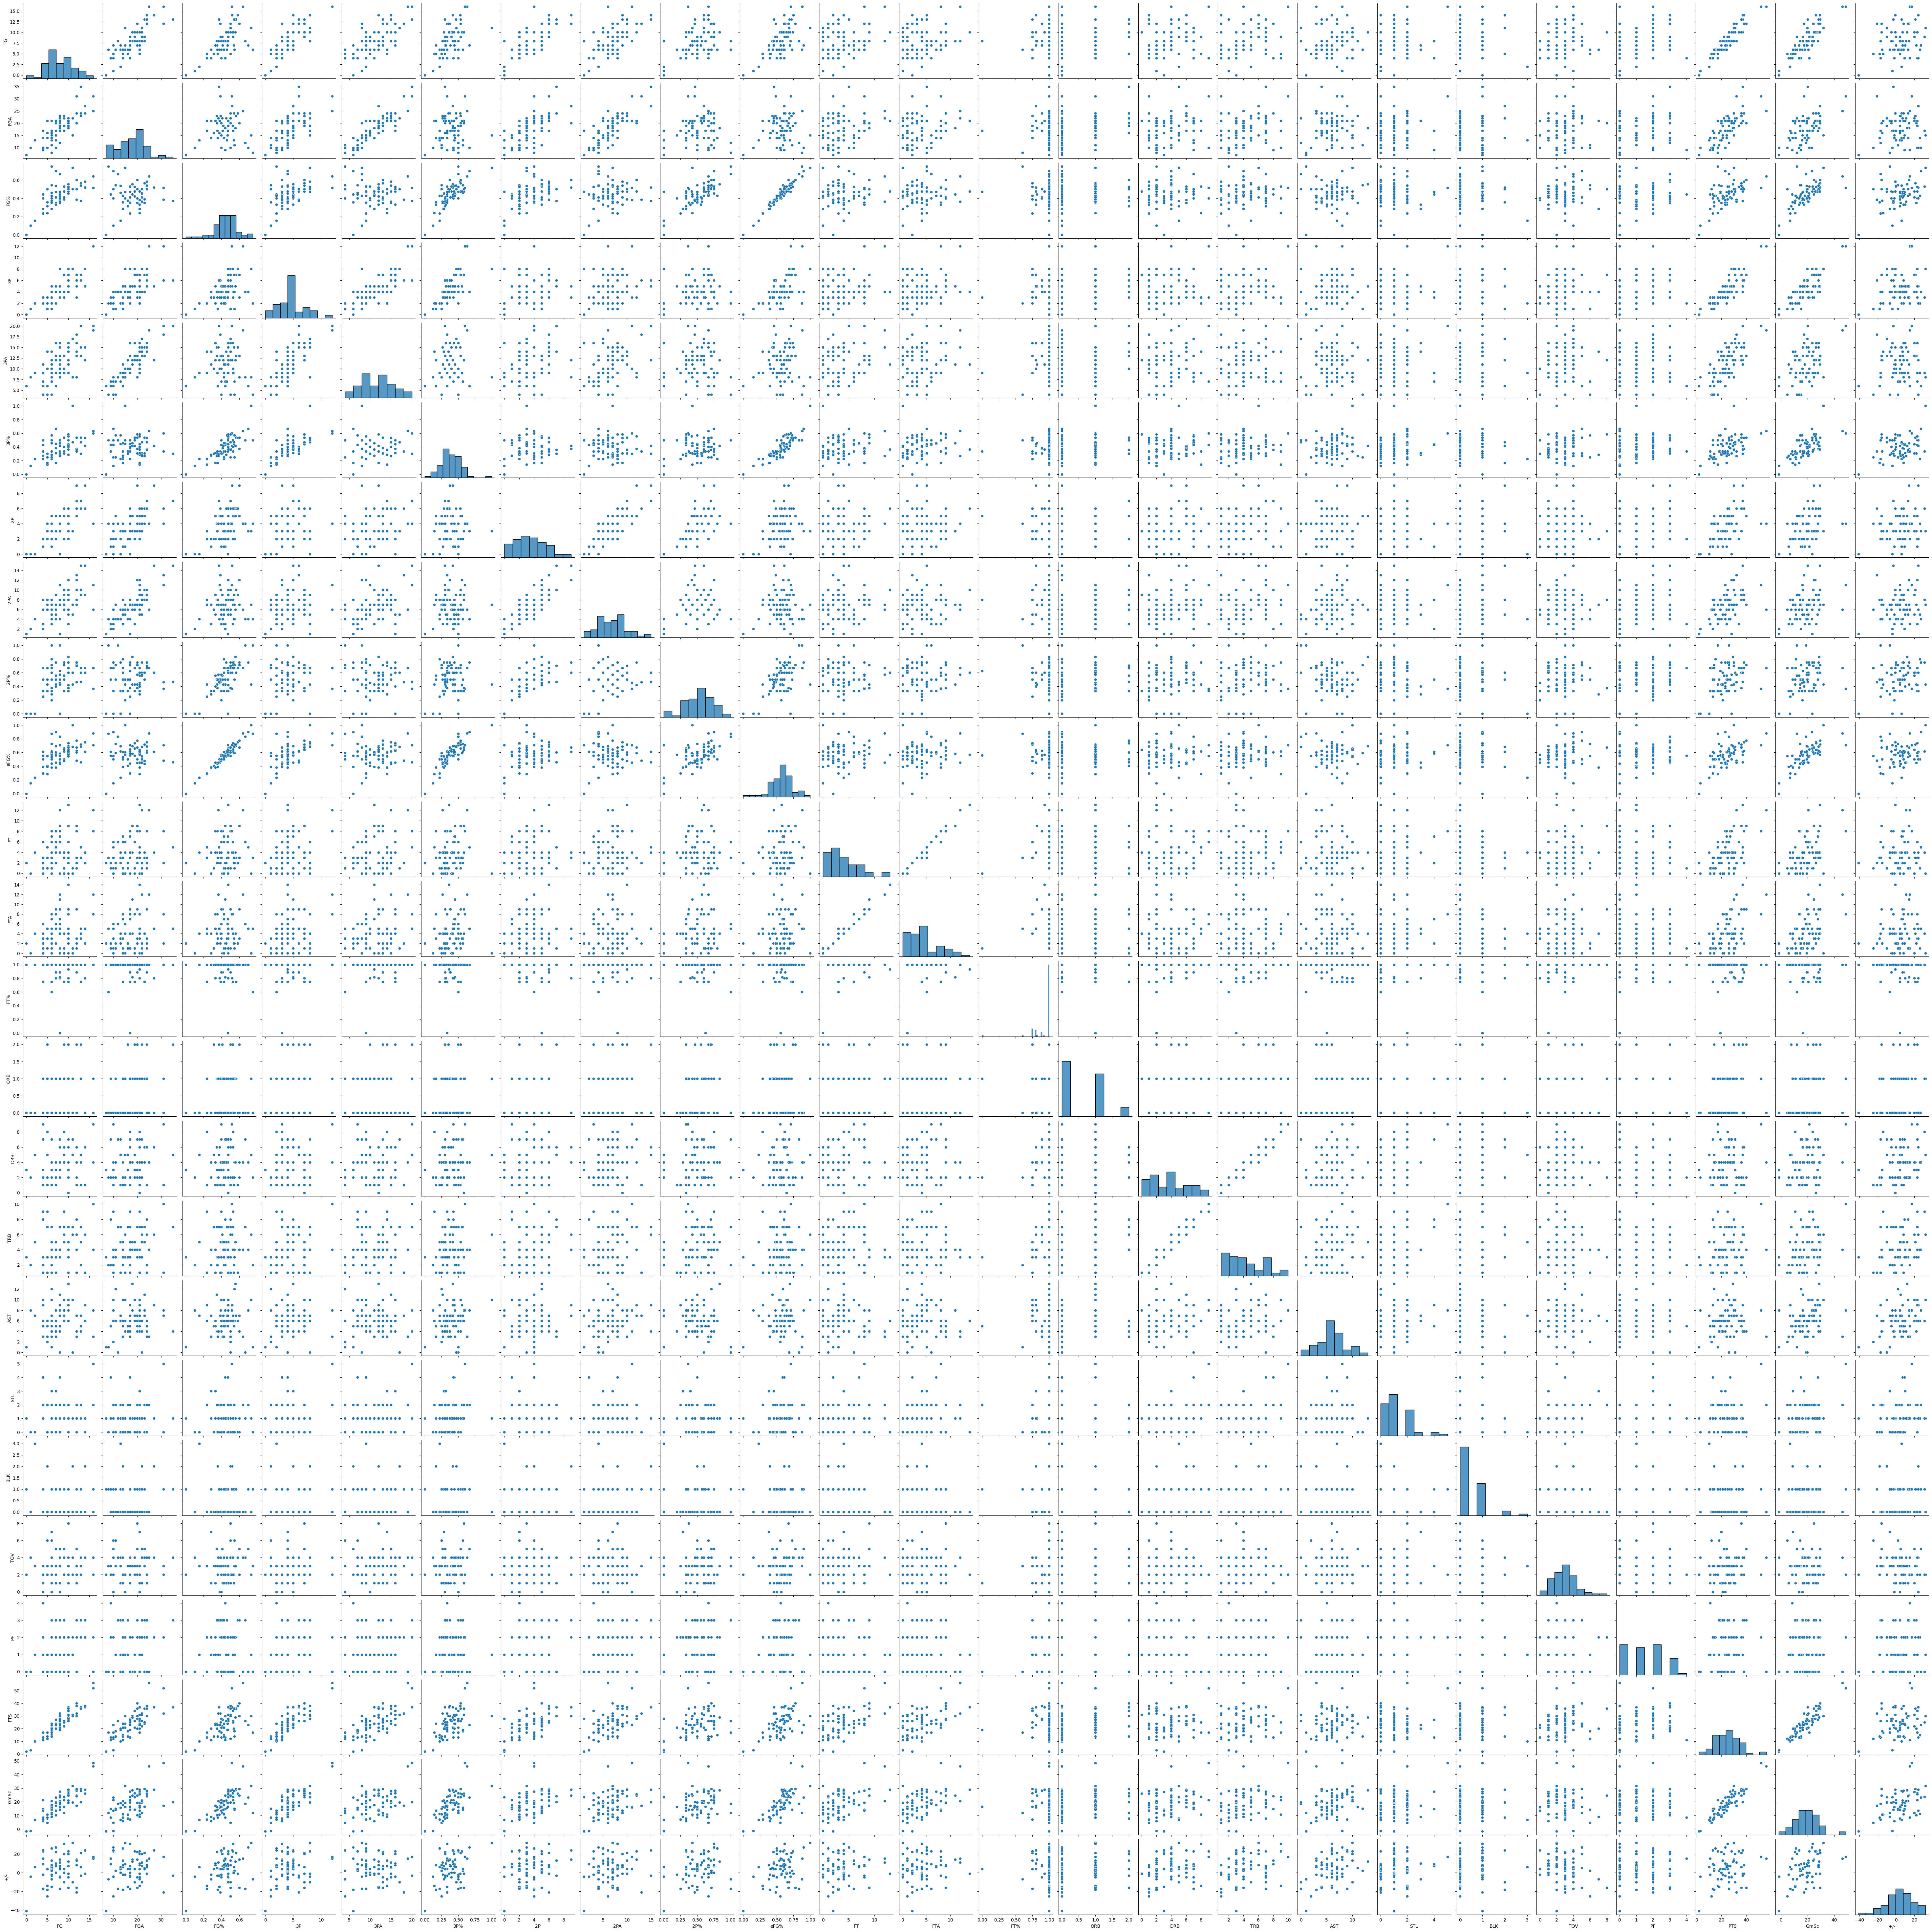

In [51]:
sns.pairplot(df)


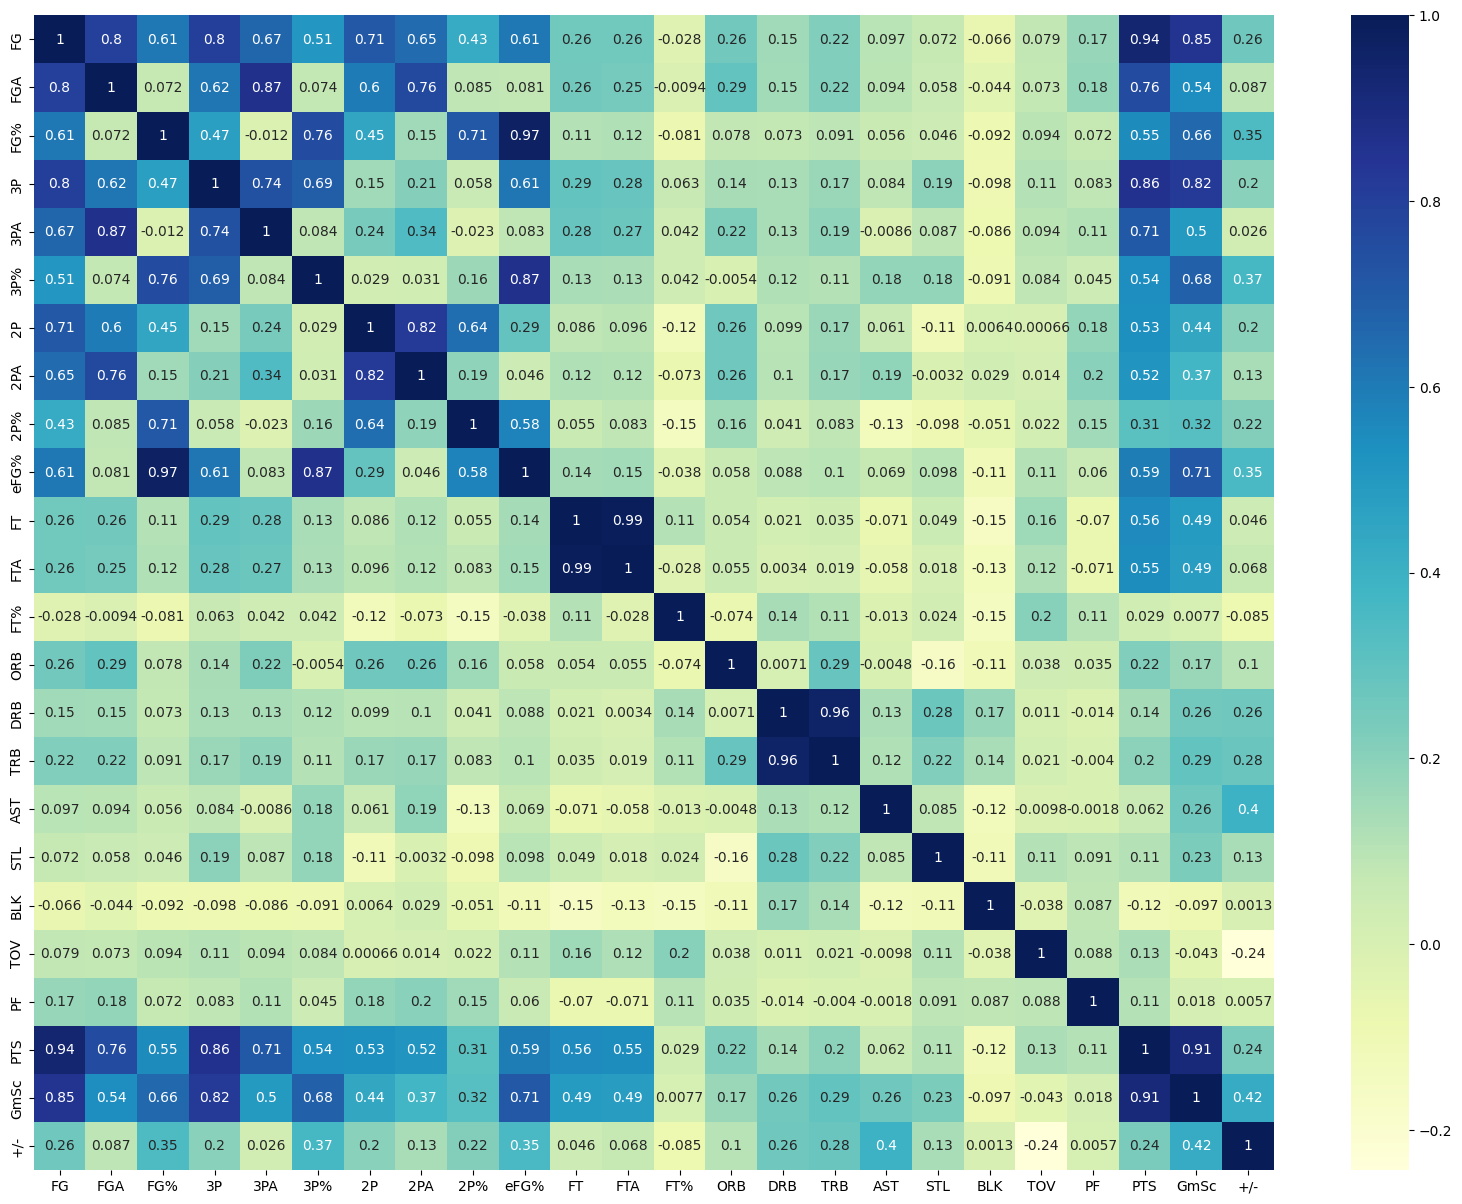

In [55]:
# co_mtx = data.corr(numeric_only=True)

# # Print correlation matrix
# print(co_mtx)

# # Plot correlation heatmap
# sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.figure(figsize=(20, 15))
df_corr = df.corr(numeric_only=True)
sns.heatmap(df_corr,cmap="YlGnBu", annot=True)
plt.show()

In [59]:
df = df.drop(['BLK', 'STL', 'AST', 'TRB', 'DRB', 'ORB', '+/-'], axis=1)

In [67]:
df['Date'] = pd.to_datetime(df['Date'])

/var/folders/vq/_942w60957g25jrq79h00p140000gq/T/ipykernel_1995/2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [71]:
df = df.drop(columns='Date', axis=1)

In [80]:
df = df.drop(columns='MP')

In [81]:
df

,designation,Opp,GS,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,TOV,PF,PTS,GmSc
0,away,POR,*,4.0,10.0,0.400,3.0,7.0,0.429,1.0,3.0,0.333,0.550,6.0,6.0,1.0,2.0,0.0,17.0,21.3
1,away,UTA,*,7.0,20.0,0.350,4.0,13.0,0.308,3.0,7.0,0.429,0.450,2.0,2.0,1.0,3.0,3.0,20.0,10.3
2,home,LAC,*,6.0,11.0,0.545,4.0,7.0,0.571,2.0,4.0,0.500,0.727,2.0,2.0,1.0,6.0,1.0,18.0,14.4
6,away,WAS,*,7.0,15.0,0.467,4.0,9.0,0.444,3.0,6.0,0.500,0.600,6.0,6.0,1.0,2.0,1.0,24.0,19.4
7,away,BOS,*,8.0,17.0,0.471,4.0,9.0,0.444,4.0,8.0,0.500,0.588,7.0,7.0,1.0,3.0,2.0,27.0,27.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,home,HOU,*,1.0,10.0,0.100,1.0,8.0,0.125,0.0,2.0,0.000,0.150,0.0,0.0,NaN,4.0,0.0,3.0,-1.4
78,away,PHO,*,9.0,17.0,0.529,3.0,9.0,0.333,6.0,8.0,0.750,0.618,4.0,4.0,1.0,2.0,0.0,25.0,23.7
79,home,SAS,*,12.0,24.0,0.500,5.0,14.0,0.357,7.0,10.0,0.700,0.604,1.0,1.0,1.0,1.0,0.0,30.0,24.3
80,away,POR,*,6.0,14.0,0.429,2.0,8.0,0.250,4.0,6.0,0.667,0.500,0.0,0.0,NaN,1.0,2.0,14.0,10.9


In [87]:
cats = ['designation', 'Opp']

In [88]:
dummies = pd.get_dummies(df[cats], prefix=cats, dtype=int)

In [89]:
dummies

,designation_away,designation_home,Opp_ATL,Opp_BOS,Opp_BRK,Opp_CHI,Opp_CHO,Opp_CLE,Opp_DAL,Opp_DEN,...,Opp_OKC,Opp_ORL,Opp_PHI,Opp_PHO,Opp_POR,Opp_SAC,Opp_SAS,Opp_TOR,Opp_UTA,Opp_WAS
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
7,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
78,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
79,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
80,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [91]:
df = df.drop(columns='GS')

In [93]:
df.drop(columns=cats, inplace=True)

In [94]:
df = df.join(dummies)

In [95]:
df

,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,...,Opp_OKC,Opp_ORL,Opp_PHI,Opp_PHO,Opp_POR,Opp_SAC,Opp_SAS,Opp_TOR,Opp_UTA,Opp_WAS
0,4.0,10.0,0.400,3.0,7.0,0.429,1.0,3.0,0.333,0.550,...,0,0,0,0,1,0,0,0,0,0
1,7.0,20.0,0.350,4.0,13.0,0.308,3.0,7.0,0.429,0.450,...,0,0,0,0,0,0,0,0,1,0
2,6.0,11.0,0.545,4.0,7.0,0.571,2.0,4.0,0.500,0.727,...,0,0,0,0,0,0,0,0,0,0
6,7.0,15.0,0.467,4.0,9.0,0.444,3.0,6.0,0.500,0.600,...,0,0,0,0,0,0,0,0,0,1
7,8.0,17.0,0.471,4.0,9.0,0.444,4.0,8.0,0.500,0.588,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,1.0,10.0,0.100,1.0,8.0,0.125,0.0,2.0,0.000,0.150,...,0,0,0,0,0,0,0,0,0,0
78,9.0,17.0,0.529,3.0,9.0,0.333,6.0,8.0,0.750,0.618,...,0,0,0,1,0,0,0,0,0,0
79,12.0,24.0,0.500,5.0,14.0,0.357,7.0,10.0,0.700,0.604,...,0,0,0,0,0,0,1,0,0,0
80,6.0,14.0,0.429,2.0,8.0,0.250,4.0,6.0,0.667,0.500,...,0,0,0,0,1,0,0,0,0,0


In [97]:
one_hot_cols = df.columns[(df.nunique() == 2) & (df.max() == 1) & (df.min() == 0)]
numeric_cols = df.columns.difference(one_hot_cols)

In [99]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [112]:
y = df['PTS']


In [ ]:
y

,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,...,Opp_OKC,Opp_ORL,Opp_PHI,Opp_PHO,Opp_POR,Opp_SAC,Opp_SAS,Opp_TOR,Opp_UTA,Opp_WAS
0,4.0,10.0,0.400,3.0,7.0,0.429,1.0,3.0,0.333,0.550,...,0,0,0,0,1,0,0,0,0,0
1,7.0,20.0,0.350,4.0,13.0,0.308,3.0,7.0,0.429,0.450,...,0,0,0,0,0,0,0,0,1,0
2,6.0,11.0,0.545,4.0,7.0,0.571,2.0,4.0,0.500,0.727,...,0,0,0,0,0,0,0,0,0,0
6,7.0,15.0,0.467,4.0,9.0,0.444,3.0,6.0,0.500,0.600,...,0,0,0,0,0,0,0,0,0,1
7,8.0,17.0,0.471,4.0,9.0,0.444,4.0,8.0,0.500,0.588,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,1.0,10.0,0.100,1.0,8.0,0.125,0.0,2.0,0.000,0.150,...,0,0,0,0,0,0,0,0,0,0
78,9.0,17.0,0.529,3.0,9.0,0.333,6.0,8.0,0.750,0.618,...,0,0,0,1,0,0,0,0,0,0
79,12.0,24.0,0.500,5.0,14.0,0.357,7.0,10.0,0.700,0.604,...,0,0,0,0,0,0,1,0,0,0
80,6.0,14.0,0.429,2.0,8.0,0.250,4.0,6.0,0.667,0.500,...,0,0,0,0,1,0,0,0,0,0


In [115]:
df_main = df.copy()

In [116]:
X = df_main.drop(columns="PTS", axis=1)

In [145]:
z = df[65:]
df_data = df[:65]

In [146]:
y = df_data['PTS']
X = df_data.drop('PTS', axis=1)

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42,
)

In [148]:
from sklearn.linear_model import LinearRegression

In [149]:
model = LinearRegression()


In [150]:
model.fit(X_train, y_train)


LinearRegression()

In [152]:
y_pred = model.predict(X_test)


In [153]:
y_pred

array([40., 23., 17., 27., 12., 13., 23., 14., 36., 26., 18., 26., 37.,
       28., 14., 11., 24.])

In [155]:
y_test

62    40.0
72    23.0
0     17.0
54    27.0
8     12.0
73    13.0
21    23.0
15    14.0
76    36.0
38    26.0
41    18.0
12    26.0
50    37.0
16    28.0
42    14.0
31    11.0
6     24.0
Name: PTS, dtype: float64

In [154]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")


Mean Squared Error: 0.00
R-squared Score: 1.00


In [161]:
z.PTS

77     3.0
78    25.0
79    30.0
80    14.0
81    36.0
Name: PTS, dtype: float64

In [162]:
z_copy = z.copy()
z_copy = z_copy.drop("PTS", axis=1)

In [163]:
model.predict(z_copy)

array([ 3., 25., 30., 14., 36.])

In [166]:
df_data_only = df_data.drop('PTS', axis=1)

In [169]:
df_data_target = df_data['PTS']

In [171]:
y_pred = model.predict(df_data_only)

In [174]:
mse = mean_squared_error(df_data_target, y_pred)
r2 = r2_score(df_data_target, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 0.00
R-squared Score: 1.00


In [175]:
print(np.intersect1d(X_train, X_test).shape)

(43,)


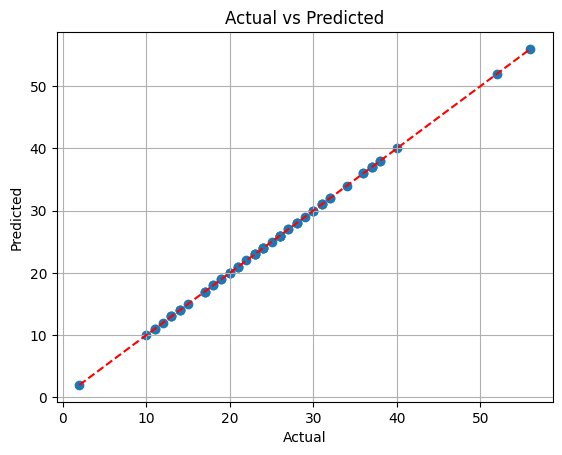

In [183]:
import matplotlib.pyplot as plt

plt.scatter(df_data_target, y_pred)
plt.plot([df_data_target.min(), df_data_target.max()], [df_data_target.min(), df_data_target.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()


In [185]:
df_data_only.to_csv('df_Steph.csv', index=False)

In [190]:
playoffs = pd.read_csv('df_Steph.csv')

In [191]:
playoffs

,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,...,Opp_OKC,Opp_ORL,Opp_PHI,Opp_PHO,Opp_POR,Opp_SAC,Opp_SAS,Opp_TOR,Opp_UTA,Opp_WAS
0,12.0,19.0,0.632,5,9.00,0.55600,7,10.0,0.70000,0.763,...,0,0,0,0,0,0,0,0,0,0
1,6.0,15.0,0.400,4,9.00,0.44400,2,6.0,0.33300,0.533,...,0,0,0,0,0,0,0,0,0,0
2,12.0,23.0,0.522,5,13.00,0.38500,7,10.0,0.70000,0.630,...,0,0,0,0,0,0,0,0,0,0
3,16.0,13.0,0.462,2,8.00,0.35000,4,4.0,0.80000,0.538,...,0,0,0,0,0,0,0,0,0,0
4,11.5,17.5,0.504,4,9.75,0.43375,5,7.5,0.63325,0.616,...,0,0,0,0,0,0,0,0,0,0
5,12.0,23.0,0.522,7,15.00,0.46700,5,8.0,0.62500,0.674,...,0,0,0,0,0,0,1,0,0,0


In [192]:
y_pred = model.predict(playoffs)

In [193]:
y_pred

array([31.        , 20.        , 36.        , 33.66666667, 30.16666667,
       33.        ])

In [194]:
import pickle

with open('model.pkl','wb') as f:
    pickle.dump(model,f)

# # load
# with open('model.pkl', 'rb') as f:
#     clf2 = pickle.load(f)

In [195]:
import joblib

joblib.dump(model, 'linear_model.pkl')

['linear_model.pkl']

In [205]:
model.predict(pd.read_json(playoffs.to_json()))

/var/folders/vq/_942w60957g25jrq79h00p140000gq/T/ipykernel_1995/2881399118.py:1: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  model.predict(pd.read_json(playoffs.to_json()))


array([31.        , 20.        , 36.        , 33.66666667, 30.16666667,
       33.        ])

In [ ]:
playoffs = pd.read_csv

In [24]:
playoffs[-1:].T

,5
FG,12.000
FGA,23.000
FG%,0.522
3P,7.000
3PA,15.000
3P%,0.467
2P,5.000
2PA,8.000
2P%,0.625
eFG%,0.674


In [19]:
pd.read_json(playoffs.to_json())


/var/folders/vq/_942w60957g25jrq79h00p140000gq/T/ipykernel_74628/3712248992.py:1: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  pd.read_json(playoffs.to_json())


,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,...,Opp_OKC,Opp_ORL,Opp_PHI,Opp_PHO,Opp_POR,Opp_SAC,Opp_SAS,Opp_TOR,Opp_UTA,Opp_WAS
0,12.0,19.0,0.632,5,9.00,0.55600,7,10.0,0.70000,0.763,...,0,0,0,0,0,0,0,0,0,0
1,6.0,15.0,0.400,4,9.00,0.44400,2,6.0,0.33300,0.533,...,0,0,0,0,0,0,0,0,0,0
2,12.0,23.0,0.522,5,13.00,0.38500,7,10.0,0.70000,0.630,...,0,0,0,0,0,0,0,0,0,0
3,16.0,13.0,0.462,2,8.00,0.35000,4,4.0,0.80000,0.538,...,0,0,0,0,0,0,0,0,0,0
4,11.5,17.5,0.504,4,9.75,0.43375,5,7.5,0.63325,0.616,...,0,0,0,0,0,0,0,0,0,0
5,12.0,23.0,0.522,7,15.00,0.46700,5,8.0,0.62500,0.674,...,0,0,0,0,0,0,1,0,0,0


In [13]:
import pickle

def load_model():
    with open('model.pkl', 'rb') as f:
        model = pickle.load(f)

    return model

In [16]:
model.predict(data).tolist()

[30.999999999999996,
 19.999999999999993,
 35.999999999999964,
 33.666666666666686,
 30.16666666666666,
 33.00000000000002]

In [25]:
playoffs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 46 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   FG                6 non-null      float64
 1   FGA               6 non-null      float64
 2   FG%               6 non-null      float64
 3   3P                6 non-null      int64  
 4   3PA               6 non-null      float64
 5   3P%               6 non-null      float64
 6   2P                6 non-null      int64  
 7   2PA               6 non-null      float64
 8   2P%               6 non-null      float64
 9   eFG%              6 non-null      float64
 10  FT                6 non-null      int64  
 11  FTA               6 non-null      float64
 12  TOV               6 non-null      int64  
 13  PF                6 non-null      int64  
 14  GmSc              6 non-null      float64
 15  designation_away  6 non-null      int64  
 16  designation_home  6 non-null      int64  
 17  O